In [95]:
from pathlib import Path
from PIL import Image
import hashlib
from torchvision import datasets
import matplotlib.pyplot as plt
from collections import Counter
import random
import os
random.seed(42)

# *Corrupted Image*

In [65]:
def find_corrupted_images(folder_path):
    corrupted_images = []

    for image_path in Path(folder_path).rglob("*"):
        if image_path.is_file():
            try:
                with Image.open(image_path) as image:
                    image.verify()
            except Exception:
                corrupted_images.append(image_path)

    return corrupted_images

In [96]:
train_path = Path("../data/train")
test_path = Path("../data/test")

print("Train path:")
print(train_path.resolve())
print("Exists:", train_path.exists())

print("\nTest path:")
print(test_path.resolve())
print("Exists:", test_path.exists())

Train path:
G:\AiCourseMaktab\Projects\Traffic Vehicles\data\train
Exists: True

Test path:
G:\AiCourseMaktab\Projects\Traffic Vehicles\data\test
Exists: True


In [98]:


image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

count_train = 0
count_test = 0

for root, dirs, files in os.walk(train_path):
    for file in files:
        if file.lower().endswith(tuple(image_extensions)):
            count_train += 1


for root, dirs, files in os.walk(test_path):
    for file in files:
        if file.lower().endswith(tuple(image_extensions)):
            count_test += 1
            
print("Total train images:", count_train)
print("Total test images:", count_test)

Total train images: 3331
Total test images: 400


In [99]:


train_corrupted = find_corrupted_images(train_path)
test_corrupted = find_corrupted_images(test_path)

print("Train corrupted:", len(train_corrupted))
print("Test corrupted:", len(test_corrupted))

print("\nTrain corrupted files:")
for path in train_corrupted:
    print(path)

print("\nTest corrupted files:")
for path in test_corrupted:
    print(path)

Train corrupted: 0
Test corrupted: 0

Train corrupted files:

Test corrupted files:


# *Duplicate Image*

In [67]:
def get_file_hash(file_path):
    hash_md5 = hashlib.md5()

    with open(file_path, "rb") as file:
        for chunk in iter(lambda: file.read(4096), b""):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()


def find_duplicates(folder_path):
    hashes = {}
    duplicates = []

    for image_path in folder_path.rglob("*"):
        
        if image_path.is_file():

            try:
                file_hash = get_file_hash(image_path)

                if file_hash in hashes:
                    duplicates.append(
                        (image_path, hashes[file_hash])
                    )
                else:
                    hashes[file_hash] = image_path

            except Exception as e:
                print("ERROR:", image_path)
                print(e)

    return duplicates




In [68]:

train_duplicates = find_duplicates(train_path)

print("Number of train duplicates:", len(train_duplicates))
if len(train_duplicates) > 0 :
    print(train_duplicates)


test_duplicates = find_duplicates(test_path)

print("Number of test duplicates:", len(test_duplicates))

Number of train duplicates: 1
[(WindowsPath('../data/train/vanet/214785158.jpg'), WindowsPath('../data/train/savari/214785158.jpg'))]
Number of test duplicates: 0


# *Train Test Duplicate Image*

In [69]:
def find_train_test_duplicates(train_path, test_path):

    train_hashes = {}

    for image_path in train_path.rglob("*"):

        if image_path.is_file():

            try:
                file_hash = get_file_hash(image_path)
                train_hashes[file_hash] = image_path

            except Exception:
                pass

    duplicates = []

    for image_path in test_path.rglob("*"):

        if image_path.is_file():

            try:
                file_hash = get_file_hash(image_path)

                if file_hash in train_hashes:
                    duplicates.append(
                        (image_path, train_hashes[file_hash])
                    )

            except Exception as e:
                print("ERROR:", image_path)
                print (e)


    return duplicates

In [70]:
train_test_duplicates = find_train_test_duplicates(train_path,test_path)

print("Count of Train/Test duplicates:" , len(train_test_duplicates))
print(train_test_duplicates)

Count of Train/Test duplicates: 8
[(WindowsPath('../data/test/ambulance/200396165.jpg'), WindowsPath('../data/train/ambulance/200396165.jpg')), (WindowsPath('../data/test/ambulance/214830125.jpg'), WindowsPath('../data/train/ambulance/214830125.jpg')), (WindowsPath('../data/test/ambulance/215713763.jpg'), WindowsPath('../data/train/ambulance/215713763.jpg')), (WindowsPath('../data/test/ambulance/216095686.jpg'), WindowsPath('../data/train/ambulance/216095686.jpg')), (WindowsPath('../data/test/ambulance/217040489.jpg'), WindowsPath('../data/train/ambulance/217040489.jpg')), (WindowsPath('../data/test/ambulance/218089422.jpg'), WindowsPath('../data/train/ambulance/218089422.jpg')), (WindowsPath('../data/test/minibus/218138154.jpg'), WindowsPath('../data/train/minibus/218138154.jpg')), (WindowsPath('../data/test/minibus/218307381.jpg'), WindowsPath('../data/train/minibus/218307381.jpg'))]


['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
ambulance 358 images (10.75%)
autobus 470 images (14.11%)
kamyun 496 images (14.89%)
kamyunet 455 images (13.66%)
minibus 413 images (12.40%)
savari 500 images (15.01%)
taxi 488 images (14.65%)
vanet 151 images (4.53%)


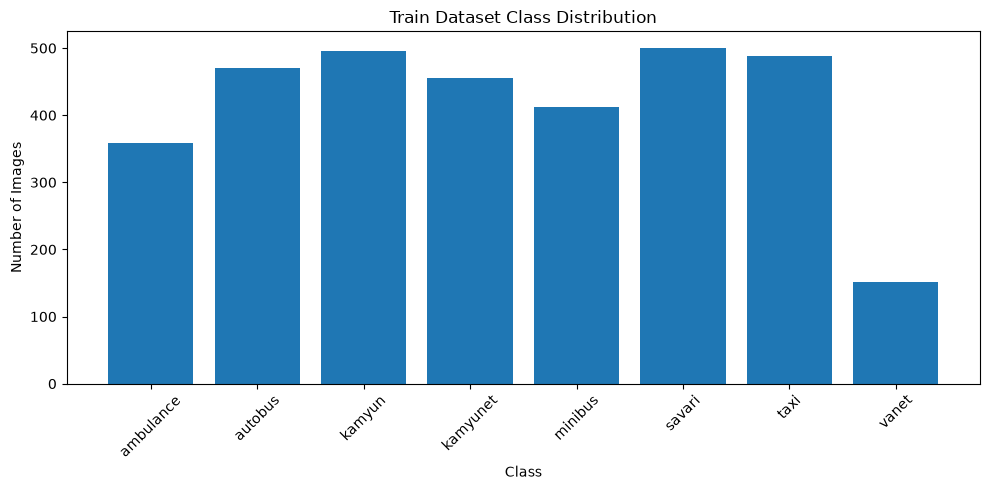

In [75]:

dataset = datasets.ImageFolder(train_path)

class_counts = Counter(dataset.targets)

classes = dataset.classes
print(classes)
counts = []

for i in range(len(classes)):
    counts.append(class_counts[i])


total = len(dataset)

for i in range(len(classes)):
    percentage = (counts[i] / total) * 100

    print(f"{classes[i]} {counts[i]} images ({percentage:.2f}%)")


plt.figure(figsize=(10, 5))

plt.bar(classes, counts)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Train Dataset Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [76]:

def inspect_images(folder_path):

    formats = Counter()
    sizes = Counter()
    modes = Counter()

    for image_path in folder_path.rglob("*"):

        if image_path.is_file():

            try:
                with Image.open(image_path) as image:

                    formats[image.format] += 1
                    sizes[image.size] += 1
                    modes[image.mode] += 1

            except Exception:
                pass

    return formats, sizes, modes

In [77]:
formats, sizes, modes = inspect_images(train_path)

print("Formats:")
for format_name, count in formats.items():
    print(format_name, ":", count)

print("\nModes:")
for mode, count in modes.items():
    print(mode, ":", count)

print("\nMost common sizes:")
for size, count in sizes.most_common(20):
    print(size, ":", count)

Formats:
JPEG : 3331

Modes:
RGB : 3331

Most common sizes:
(198, 264) : 122
(189, 252) : 107
(186, 252) : 99
(177, 240) : 68
(198, 252) : 67
(207, 276) : 56
(180, 240) : 54
(171, 228) : 44
(210, 276) : 41
(189, 240) : 41
(195, 264) : 38
(162, 216) : 34
(156, 204) : 32
(186, 240) : 32
(180, 228) : 28
(177, 228) : 24
(195, 252) : 22
(165, 216) : 18
(150, 192) : 17
(171, 216) : 14


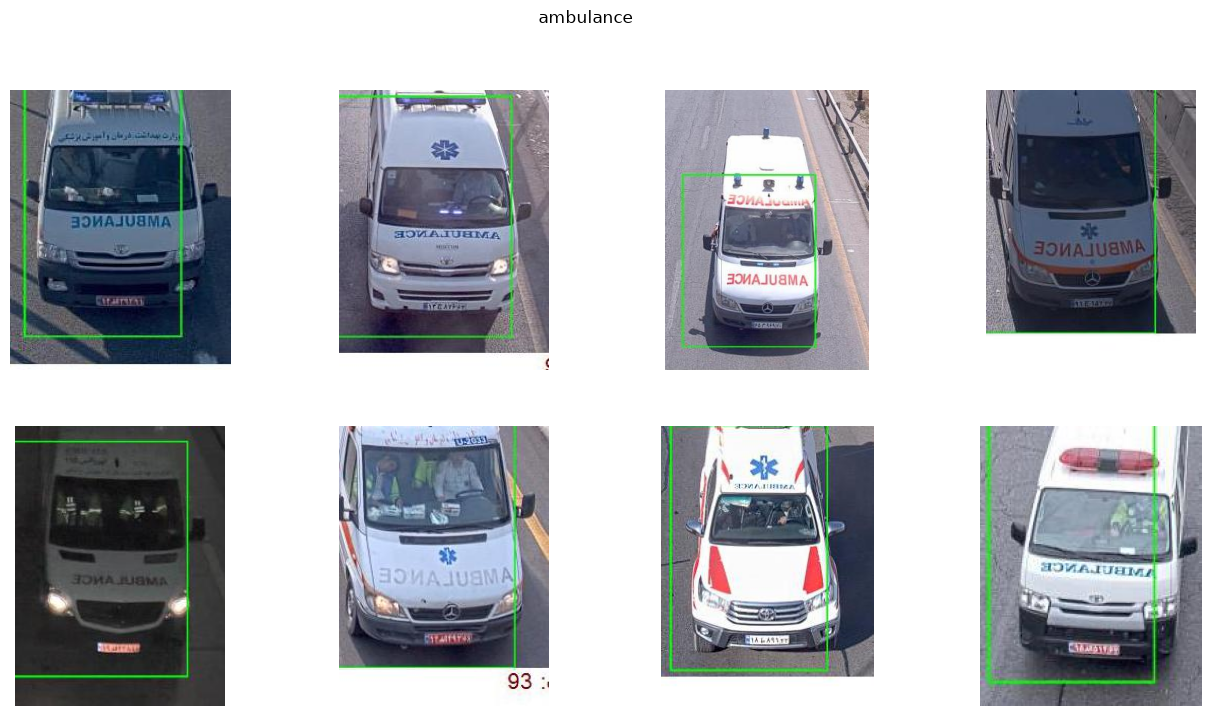

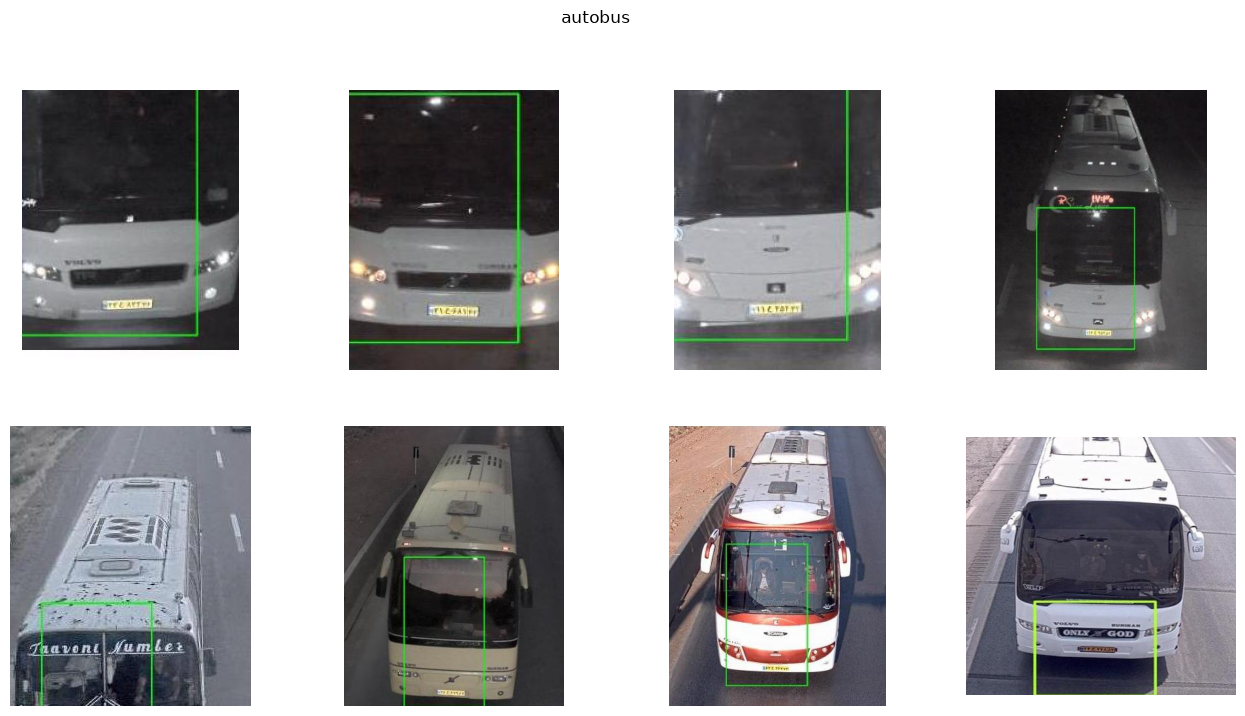

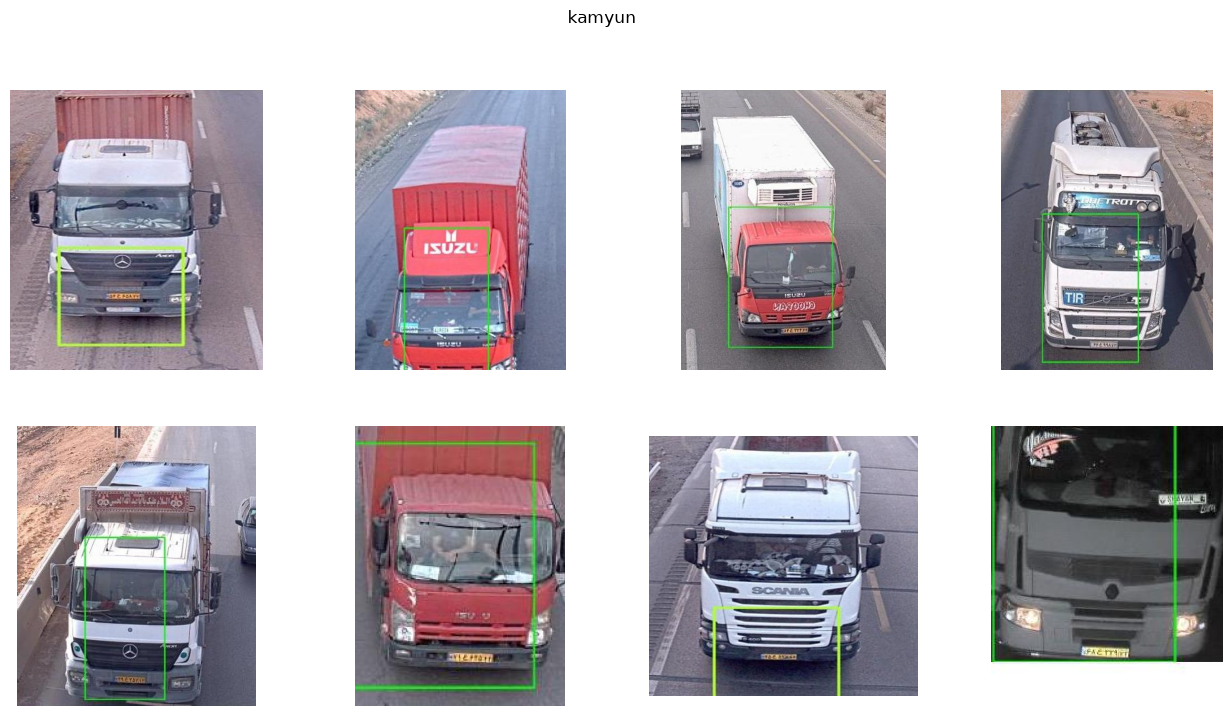

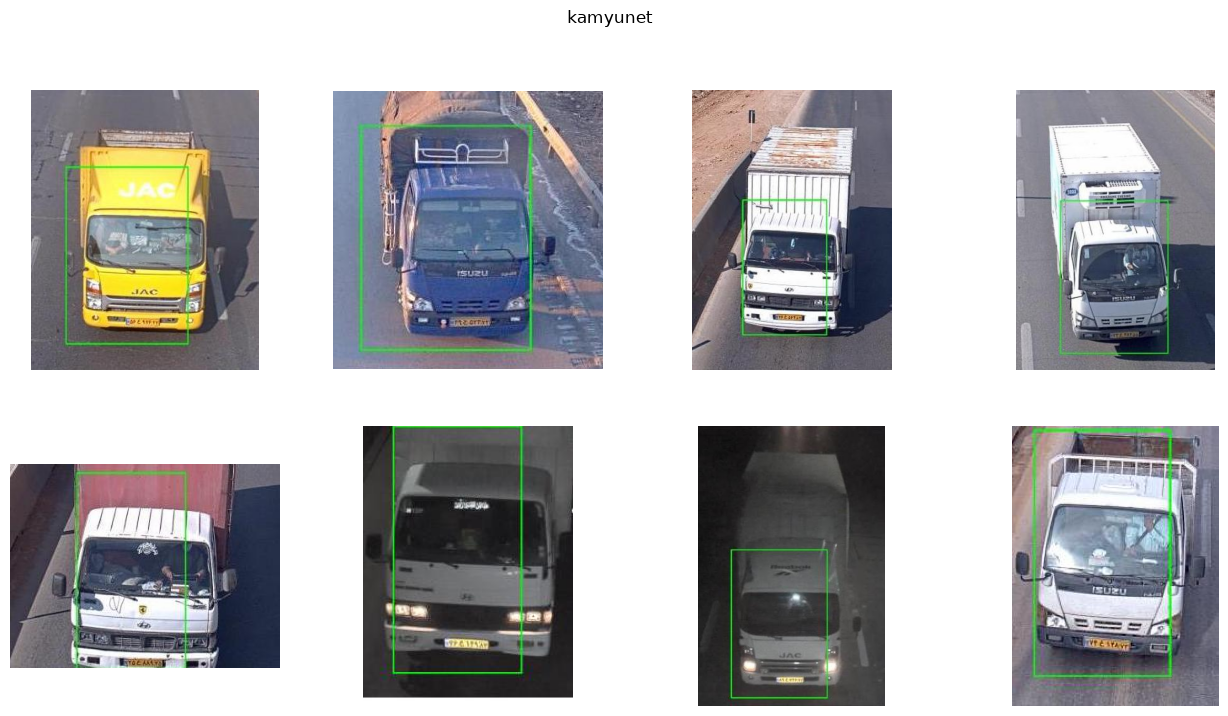

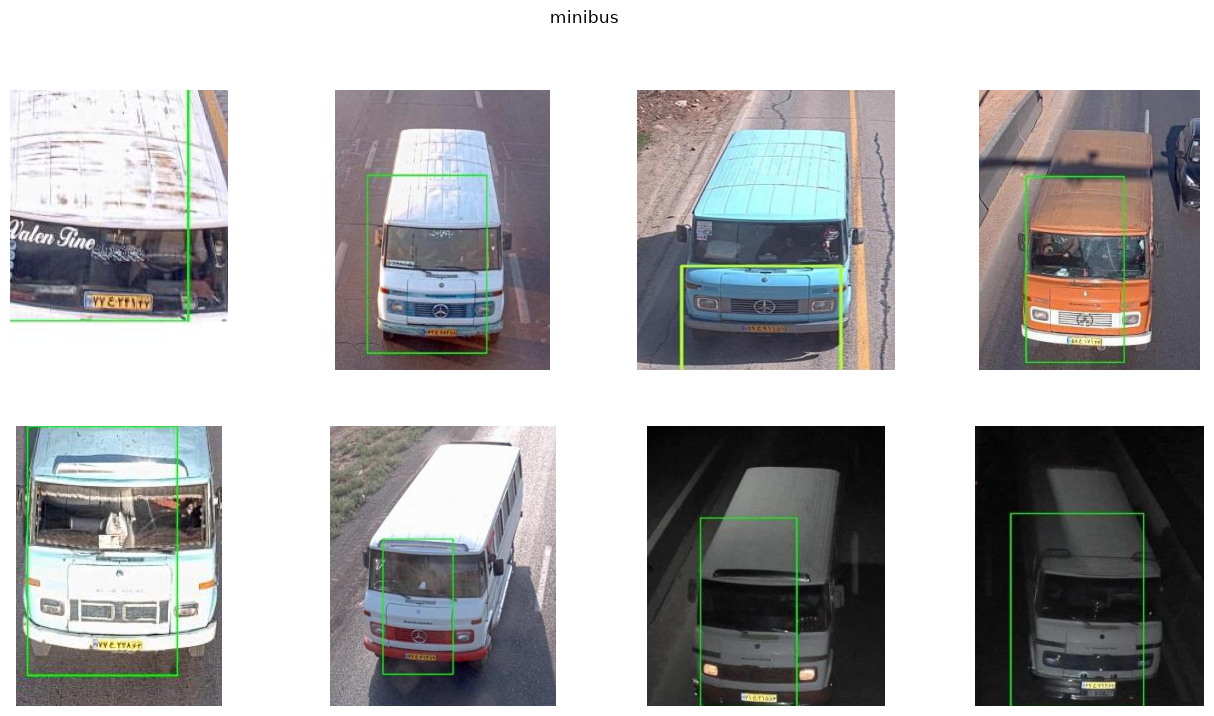

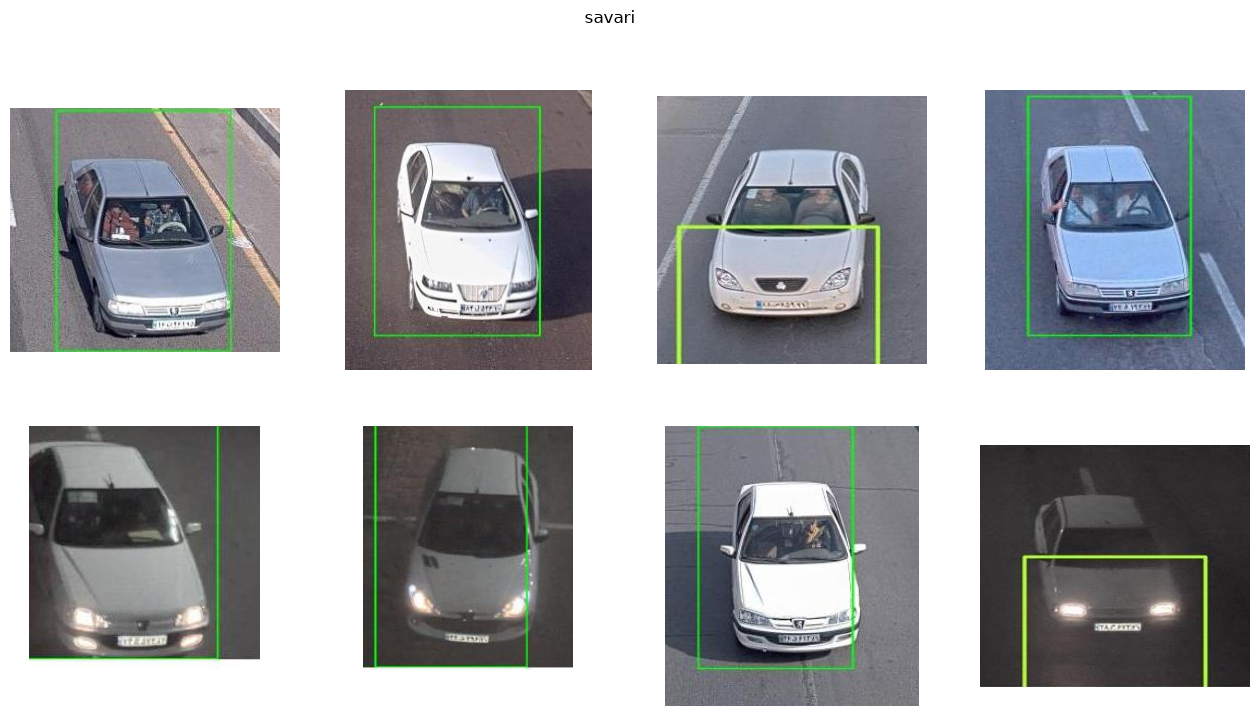

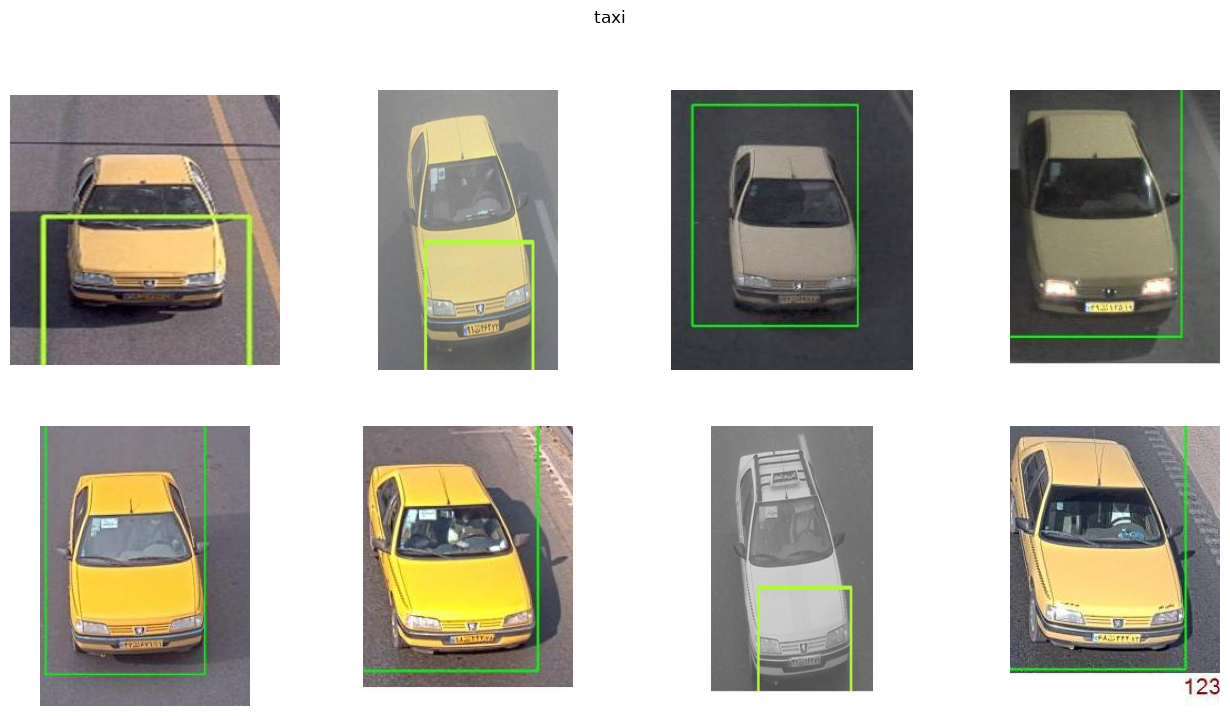

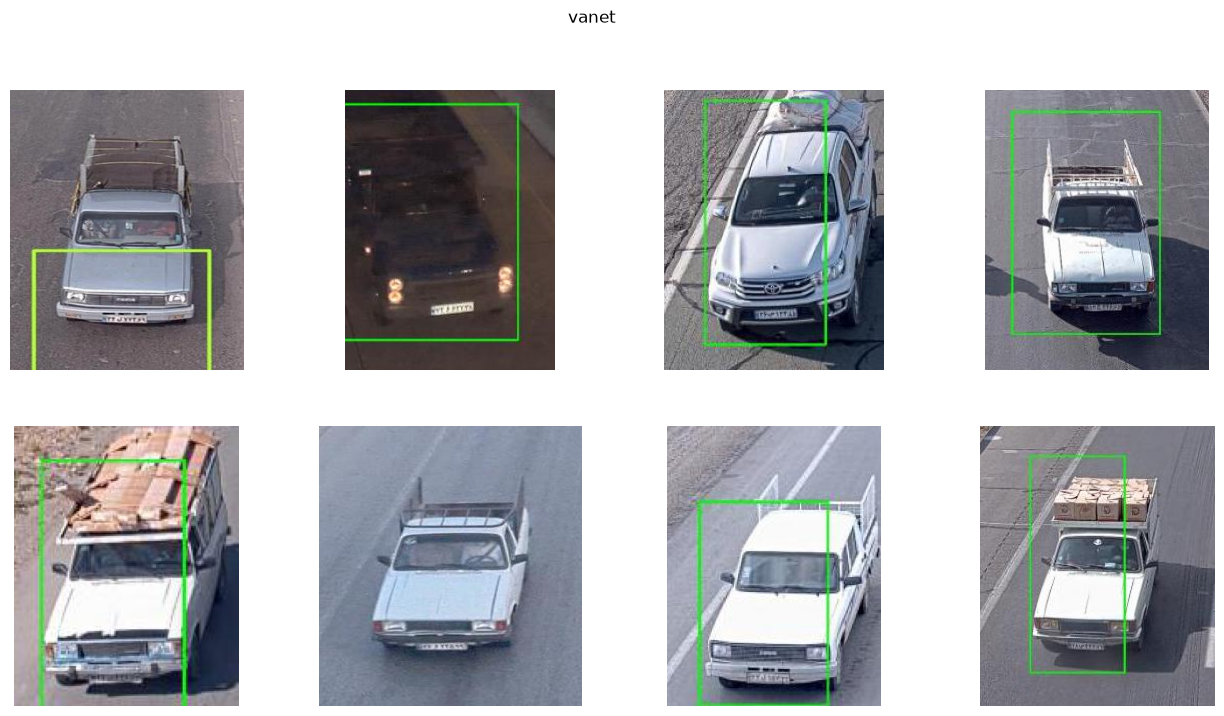

In [94]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

for class_path in sorted(train_path.iterdir()):

    if class_path.is_dir():

        image_files = []

        for image_path in sorted(class_path.iterdir()):
            if image_path.is_file():
                image_files.append(image_path)

        selected_images = random.sample(
            image_files,
            min(8, len(image_files))
        )

        plt.figure(figsize=(16, 8))

        for i in range(len(selected_images)):

            image = Image.open(selected_images[i])

            plt.subplot(2, 4, i + 1)
            plt.imshow(image)
            plt.axis("off")

        plt.suptitle(class_path.name)
        plt.show()